<a href="https://colab.research.google.com/github/robertccruz13-ship-it/sds-510-robert-cruz/blob/main/sns_data_assignment_robert_cruz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The COVID 19 pandemic significantly impacted global communication, with social media platforms like Twitter playing a key role in spreading information, opinions, and public snetiment. Hashtags became an essential tool for organizing discussions and connecting topics. This project will analyze a dataset of COVID 19 related tweets using Social Network Analysis (SNA), focusing on hastags co occurences. The goal is to identify relatiionships between topics, measure network properties, and visualize how conversations were structured during the pandemic.

In [ ]:
import os

print(os.listdir('.'))

['.config', 'sampled_covid19_tweets_2020-06-30_21.jsonl', 'sample_data']


In [ ]:
import pandas as pd
import os

file_path = "/content/sampled_covid19_tweets_2020-06-30_21.jsonl"

if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}. Please check the path and ensure the file is uploaded.")
    # Optionally, you might want to stop execution or raise an exception here
else:
    try:
        df = pd.read_json(file_path, lines=True)
        print("Successfully loaded data. Here's a preview:")
        print(df.head())
    except ValueError as e:
        print(f"Error reading JSON file: {e}. The file might be malformed or not valid JSON Lines.")
        print("You might want to inspect the file content, for example, by running: `!head -n 5 {file_path}`")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


Successfully loaded data. Here's a preview:
           created_at                   id               id_str  \
0 2020-06-30 21:39:46  1278080816615247872  1278080816615247872   
1 2020-06-30 22:11:51  1278088888867831808  1278088888867831808   
2 2020-06-30 22:03:41  1278086835508596737  1278086835508596736   
3 2020-06-30 21:47:04  1278082651623063552  1278082651623063552   
4 2020-06-30 21:48:02  1278082896134320129  1278082896134320128   

                                                text  \
0  so many questions about this #CCPChina #vaccin...   
1  @mrsjjee How would you deal with that result f...   
2  Redefine the job of a truck driver who can wor...   
3  RT @angiegxox: Wear your mask https://t.co/XDh...   
4  RT @PatrickW: I give it a week before DeSantis...   

                                              source  truncated  \
0  <a href="http://twitter.com/download/android" ...       True   
1  <a href="http://twitter.com/download/iphone" r...       True   
2  <a href="htt

In [ ]:
def extract_hastags(entities):
  if isinstance(entities, dict) and 'hashtags' in entities:
    return [tag['text'].lower()for tag in entities['hashtags']]
  else:
    return []

df['hashtags'] = df['entities'].apply(extract_hastags)
df['user_id'] = df['user'].apply(lambda x: x['id'] if isinstance(x, dict) else None)
df['created_at'] = pd.to_datetime(df['created_at'])
_df_preview = df[['text', 'hashtags', 'user_id', 'created_at']].head()
_df_preview.head()

,text,hashtags,user_id,created_at
0,so many questions about this #CCPChina #vaccin...,"[ccpchina, vaccine, tested, canadians, testing...",1214919842672906241,2020-06-30 21:39:46
1,@mrsjjee How would you deal with that result f...,[],60583625,2020-06-30 22:11:51
2,Redefine the job of a truck driver who can wor...,[],17025652,2020-06-30 22:03:41
3,RT @angiegxox: Wear your mask https://t.co/XDh...,[],1141196892686045185,2020-06-30 21:47:04
4,RT @PatrickW: I give it a week before DeSantis...,[],102656769,2020-06-30 21:48:02


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

print ("Total Tweets:", len(df))

print ('Unique Users:', df['user_id'].nunique())

all_hastags = [tag for tags in df['hashtags'] for tag in tags]
hashtag_counts = Counter(all_hastags)

print("Top Hastags:", hashtag_counts.most_common(10))

Total Tweets: 20000
Unique Users: 19444
Top Hastags: [('covid19', 675), ('coronavirus', 193), ('covidー19', 72), ('كورونا', 65), ('constitutionovercoronavirus', 63), ('covid_19', 61), ('covid', 58), ('independenciaypaz', 49), ('30jun', 38), ('quédateencasa', 38)]


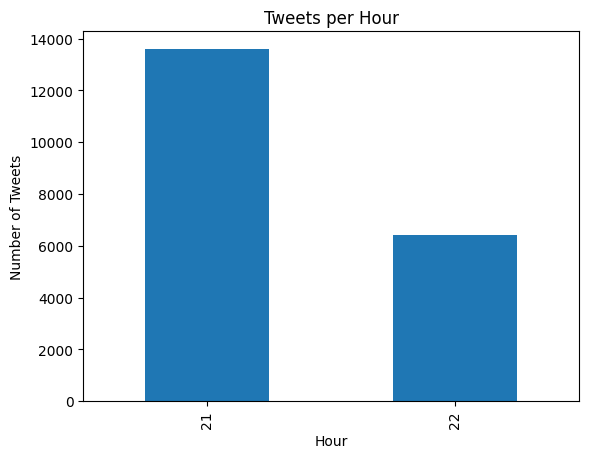

In [ ]:
tweets_per_hour = df.groupby(df['created_at'].dt.hour)['text'].size()

tweets_per_hour.plot(kind='bar')
plt.title('Tweets per Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Tweets')
plt.show()

In [ ]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

for tags in df['hashtags']:
  unique_tags = list(set(tags))

  for tag1, tag2 in combinations(unique_tags, 2):
    if G.has_edge(tag1, tag2):
      G[tag1][tag2]['weight'] += 1
    else:
      G.add_edge(tag1, tag2, weight=1)

In [ ]:
edges = nx.to_pandas_edgelist(G)
edges.to_csv("edges.csv", index=False)

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

avg_degree = sum(dict(G.degree()).values()) / num_nodes
density = nx.density(G)


print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Average Degree:", avg_degree)
print("Density:", density)

Nodes: 1749
Edges: 3850
Average Degree: 4.40251572327044
Density: 0.0025186016723515105


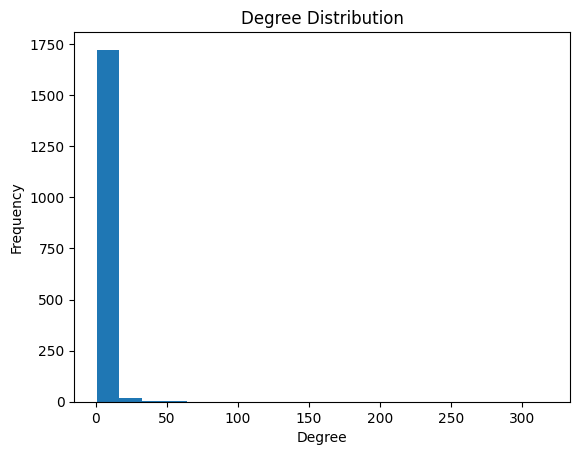

In [ ]:
degrees = [deg for node, deg in G.degree()]
plt.hist(degrees, bins=20)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12490 (\N{KATAKANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

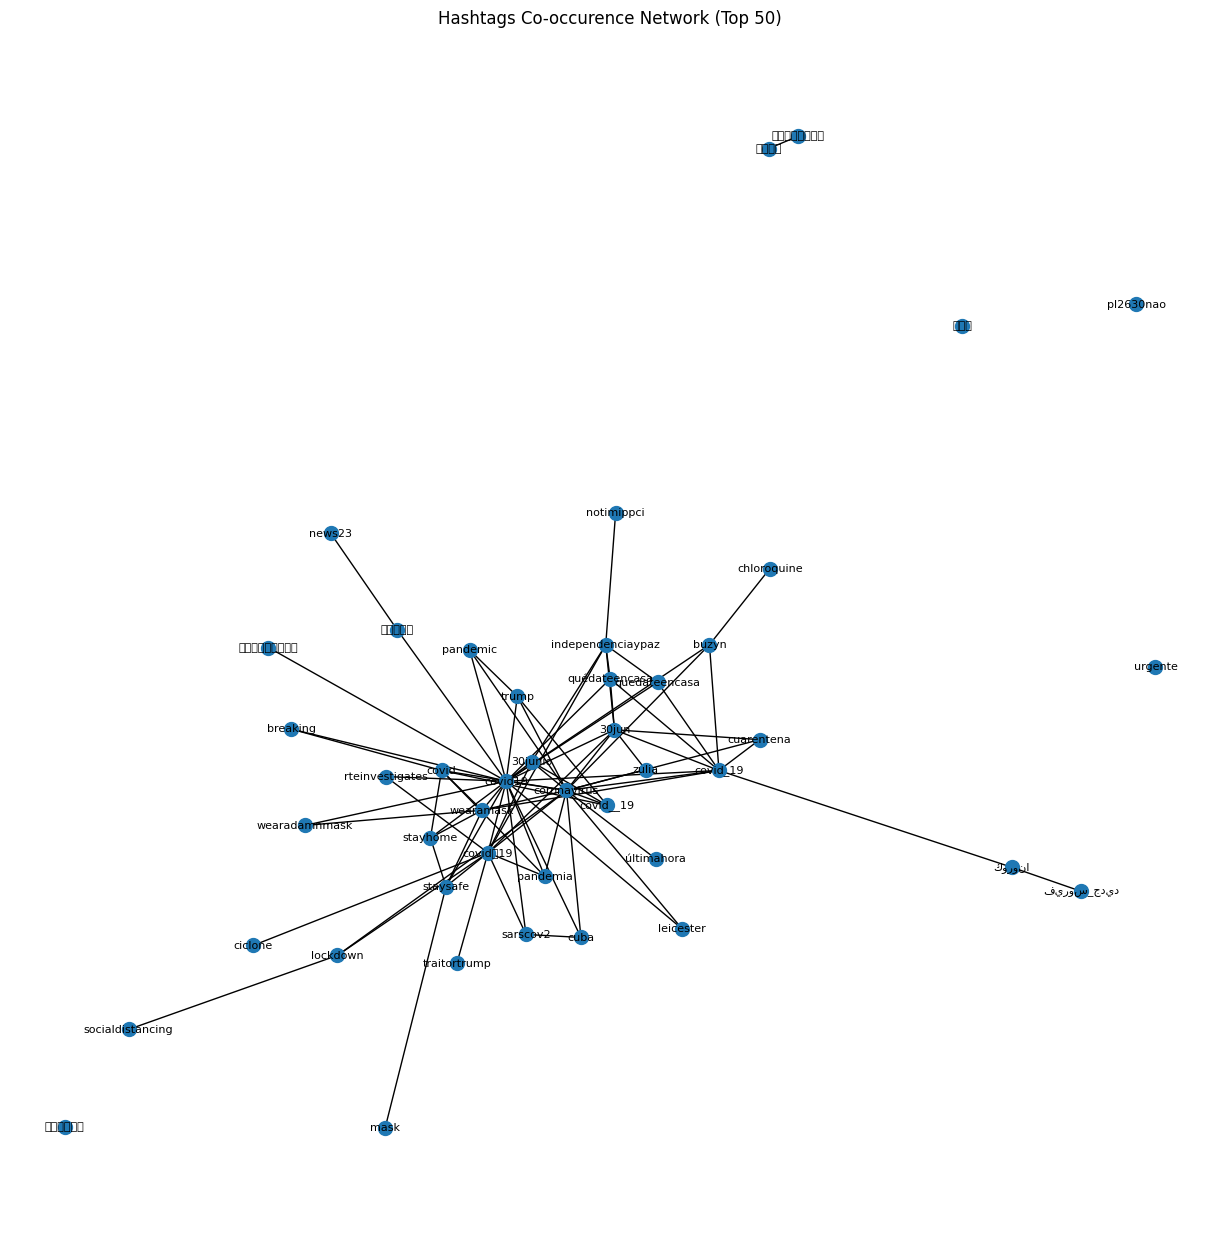

In [ ]:
top_tags = [tag for tag, count in hashtag_counts.most_common(50)]
subgraph = G.subgraph(top_tags)

plt.figure(figsize=(12, 12))

pos = nx.spring_layout(subgraph, k=0.4)
nx.draw(subgraph,pos,
        with_labels=True,
        node_size=100,
        font_size = 8)

plt.title("Hashtags Co-occurence Network (Top 50)")
plt.show()

The hastag co occurence network reveals how different COVID 19 related topics were interconnected on Twitter. Frequenlty co occuring hashtags indicate clusters of discussion, such as public health maeasures, political disocurse, and vaccination efforts. Highly connected hastags act as central hubs, suggesting dominant themes in the conversation. The relatively low density of the network indicates that discussions were spread across many topics rather than being tighly interconnected. The degree distribution shows that a small number of hashtags have many connections, while most have few. This reflects a typical social network structure where a few key topics are dominating the discourse.

This analysis demonstrated how social network analysis can be applied to social media data to uncover patterns in public discourse. By examining hastag co occurence, we identified key topics and their relationships within COVID 19 conversations. The findings highlight the role of Twitter in shaping public opinion during the pandemic and show how network analysis can reveal important insights into information and topic relationships.